In [38]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "2"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["JAX_ENABLE_X64"] = "true"

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
from lv import LV
from triangular_transport.flows.dataloaders import log_normal_reference_sampler,gaussian_reference_sampler
jax.config.update("jax_enable_x64", True)

In [43]:
seed = 0
no_samples = 1
sigma = float(jnp.sqrt(0.1))  # likelihood noise used inside LV.likelihood_pdf
u_true = jnp.array([0.83194674, 0.04134147, 1.0823151, 0.03991483])

lv = LV(
    seed=seed,
    no_samples=no_samples,
    prior_sampler=log_normal_reference_sampler,
    likelihood_sampler=log_normal_reference_sampler,
    normalize=False,
    u_true=u_true,
    sigma=sigma,
    dt0=0.1,
)

# ---- Construct a synthetic observation y_obs from the model using u_true ----
# y_obs should match what likelihood_pdf expects:
# likelihood_pdf flattens y and compares log(y) to xt.ravel().
ys_b = lv.solve_lv(lv.y0_start, u_true)      # shape (len(ts), 2)
# xt = jnp.abs(ys).ravel()                   # "mean" in log-space inside likelihood_pdf
xt = jnp.ravel(ys_b)
key = random.key(123)
y_obs = jnp.log(xt) + sigma * random.normal(key, shape=xt.shape)
# yobs = np.load("y_obs.npy")

In [47]:
np.save("y_obs.npy", y_obs)

In [48]:
np.exp(np.load("y_obs.npy"))

array([83.76926567, 25.84510297,  2.50835183, 32.38448871,  4.13838891,
        4.87191449, 15.03848533,  2.14699477, 92.59430948,  2.76237355,
        7.42370989, 90.25379286,  2.41900295, 14.31027172,  9.60992351,
        2.4013605 , 28.9850761 ,  1.3515651 ])

In [44]:
np.exp(y_obs)

array([83.76926567, 25.84510297,  2.50835183, 32.38448871,  4.13838891,
        4.87191449, 15.03848533,  2.14699477, 92.59430948,  2.76237355,
        7.42370989, 90.25379286,  2.41900295, 14.31027172,  9.60992351,
        2.4013605 , 28.9850761 ,  1.3515651 ])

In [42]:
sigma * random.normal(key, shape=xt.shape)

Array([-0.23814429, -0.00964433, -0.04649577, -0.09251576,  0.07199753,
       -0.03321092, -0.10018873,  0.63069428,  0.16706491, -0.16724524,
        0.06406902,  0.24417836, -0.0694645 ,  0.32828015,  0.0309519 ,
        0.30919633, -0.43104296,  0.1058645 ], dtype=float64)

In [12]:
print(f"This is small timestep: {ys_b}")
print(f"This is big timestep: {ys_s}")

This is small timestep: [[106.29422965  26.09552894]
 [  2.62773799  35.52356891]
 [  3.85090924   5.03643813]
 [ 16.62323377   1.14267964]
 [ 78.34817334   3.26525081]
 [  6.96302148  70.70015368]
 [  2.59301562  10.30571438]
 [  9.31704448   1.76268941]
 [ 44.60406188   1.21579977]]
This is big timestep: [[106.29417377  26.0955674 ]
 [  2.62773345  35.52353099]
 [  3.85090825   5.036432  ]
 [ 16.62323365   1.1426782 ]
 [ 78.3481832    3.26524741]
 [  6.96299637  70.70011966]
 [  2.59301152  10.30570296]
 [  9.31703421   1.7626866 ]
 [ 44.60402247   1.2157957 ]]


In [13]:
yobs_s = jnp.log(ys_s)
yobs_b = jnp.log(ys_b)

In [3]:
key = random.key(123)
xt = jnp.ravel(ys)
yobs = jnp.log(xt) + sigma * random.normal(key, shape=xt.shape)

In [16]:
x = jnp.array([-0.58417376, -0.57763122, -4.12181628, -5.35617826])

In [17]:
lv.log_likelihood_pdf(yobs_s, x)

Array(-567.9414783, dtype=float64)

In [18]:
lv.log_prior_pdf(x)

Array(-29.89428719, dtype=float64)

In [10]:
lv.log_posterior(yobs, x)

This is xt: JitTracer<float64[18]>


Array(-589.23862204, dtype=float64)

In [15]:
lv.log_prior_pdf(u_true)

Array(-23.1536567, dtype=float64)

In [ ]:
key2 = random.key(999)
u_near = u_true * jnp.exp(0.05 * random.normal(key2, shape=u_true.shape))
u_far  = u_true * jnp.exp(1.00 * random.normal(key2, shape=u_true.shape))

# ---- 1) internal consistency checks ----
post = lv.posterior(y_obs, u_near)
like = lv.likelihood_pdf(y_obs, u_near)
prior = lv.prior_pdf(u_near)

rel_err = jnp.abs(post - like * prior) / (jnp.abs(post) + 1e-12)
print("posterior vs like*prior rel err:", float(rel_err))

posterior vs like*prior rel err: 0.0


: 

In [4]:
logpost = lv.log_posterior(y_obs, u_near)
loglike = lv.log_likelihood_pdf(y_obs, u_near)
logprior = lv.log_prior_pdf(u_near)
rel_err_log = jnp.abs(logpost - (loglike + logprior)) / (jnp.abs(logpost) + 1e-12)
print("log_posterior vs loglike+logprior rel err:", float(rel_err_log))

log_posterior vs loglike+logprior rel err: 0.0


In [5]:
logpost

Array(-134976.83664613, dtype=float64)

In [6]:
loglike

Array(-134980.85366485, dtype=float64)

In [24]:
x = jnp.squeeze(u_near)
y = jnp.ravel(y_obs)

# Lognormal requires y > 0
bad = jnp.any(y <= 0.0)

xt = lv.solve_lv(lv.y0_start, x)
xt = jnp.ravel(jnp.abs(xt))  # consider removing abs later

d = y.shape[0]
var = lv.sigma**2

resid = jnp.log(y) - xt
quad = jnp.sum(resid * resid) / var

# log(1/prod(y)) = -sum(log(y))
# Normal constant: -(d/2)log(2π var)
log_like = -jnp.sum(jnp.log(y)) - 0.5 * d * jnp.log(2 * jnp.pi * var) - 0.5 * quad

In [25]:
quad

Array(inf, dtype=float32)

In [26]:
xt

Array([97.99173   , 16.966204  ,  3.6686711 , 37.107506  ,  3.7121332 ,
        5.9379506 , 13.037373  ,  1.3223205 , 53.593376  ,  1.5874029 ,
       32.51718   , 74.54871   ,  2.6475344 , 17.419928  ,  5.934492  ,
        2.9488096 , 23.351818  ,  0.99813426], dtype=float32)

In [7]:
resid

Array([         inf,   9.395155  ,  -1.0339332 ,  -1.751297  ,
        -0.07836008,  -1.2455125 ,   3.187477  ,   0.3274747 ,
        24.453217  ,   1.5495309 , -25.622066  ,  -4.3838806 ,
        -0.47206354,  -6.795928  ,   3.1668339 ,  -1.7048544 ,
        20.84591   ,   0.7065799 ], dtype=float32)

In [36]:
a = LV(seed=1, no_samples = 100, prior_sampler=log_normal_reference_sampler, likelihood_sampler=log_normal_reference_sampler, sigma=jnp.sqrt(0.1).item())

In [37]:
x = jnp.ones(4)
a.prior_pdf(x)

Array(1.4956374e-09, dtype=float32)

In [38]:
y = jnp.ones(18)
a.likelihood_pdf(y, x)

Array(0., dtype=float32)

In [8]:
xt = a.solve_lv(jnp.array([30, 1]), x)
xt = xt.ravel()

In [40]:
y_dim = 18
# var_like = jnp.sqrt(0.1) ** 2
var_like = a.sigma ** 2
cov_mat = jnp.diag(jnp.full(y_dim, var_like))
inv_cov_mat = jnp.diag(jnp.full(y_dim, 1 / var_like))

In [41]:
jnp.exp((-1 / 2) * jnp.sum((jnp.log(y) - xt) * (inv_cov_mat @ (jnp.log(y) - xt))))

Array(0., dtype=float32)

In [42]:
(1 / (jnp.prod(y))) * (1 / (2 * jnp.pi)) ** (int(y_dim) / 2) * (1 / jnp.prod(jnp.diag(cov_mat))) ** (0.5)

Array(65.52109, dtype=float32)

In [34]:
1 / jnp.prod(jnp.diag(cov_mat)) ** (0.5)

Array(9.999998e+08, dtype=float32)

In [28]:
jnp.sqrt(0.1)

Array(0.31622776, dtype=float32, weak_type=True)

In [25]:
(1 / jnp.prod(jnp.diag(cov_mat))) ** (0.5)

Array(inf, dtype=float32)

In [21]:
jnp.exp((jnp.sum((jnp.log(y) - xt) * (inv_cov_mat @ (jnp.log(y) - xt)))) / -2)

Array(0., dtype=float32)

In [9]:
d = jnp.ones((9, 1))
t = jnp.zeros((9, 1))
dt = jnp.hstack([d, t])
dt.ravel()

Array([1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
       0.], dtype=float32)

In [8]:
len(jnp.arange(0 + 2, 20, step=2))

9

In [ ]:
a.prior_pdf(x)

Array(1.4956374e-09, dtype=float32)

: 

In [15]:
a.u_dim

4

In [16]:
(1 / (2 * jnp.pi)) ** (int(a.u_dim) / 2)

0.025330295910584447

In [19]:
cov_mat = jnp.diag(jnp.full(a.u_dim, a.std_prior))
(1 / jnp.prod(jnp.diag(cov_mat))) ** (0.5)

Array(2., dtype=float32)

In [26]:
inv_cov_mat = jnp.diag(jnp.full(a.u_dim, 1 / a.std_prior))
(-1 / 2) * (jnp.log(x) - a.mu_base) * (inv_cov_mat @ (jnp.log(x) - a.mu_base))

Array([-0.01104854, -6.3639607 , -0.01104854, -6.3639607 ], dtype=float32)

In [6]:
mu = jnp.array([-0.125, -3.0, -0.125, -3.0])
sigma = 1/jnp.sqrt(2)

x = jnp.ones(4)

Sigma_inv = jnp.eye(4) / sigma**2
det_Sigma = sigma**(2*4)

quad = (jnp.log(x)-mu) @ Sigma_inv @ (jnp.log(x)-mu)

pdf = (
    jnp.exp(-0.5*quad)
    / ((2*jnp.pi)**2 * jnp.sqrt(det_Sigma))
)

print(pdf)

1.4956374e-09


In [36]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [38]:
us1 = np.load("true_samps/true_us_obs.npy")[::20, :]
us2 = np.load("true_samps/true_us_obs_2.npy")[::20, :]
us4 = np.load("true_samps/true_us_obs_4.npy")[::20, :]

us = np.vstack([us1, us2, us4])

In [39]:
np.exp(np.mean(us, axis=0))

array([0.8147521 , 0.03846651, 1.08777449, 0.04108938])

In [40]:
u_true = np.array([0.83194674, 0.04134147, 1.0823151, 0.03991483])

In [41]:
np.exp(us)

array([[0.83106636, 0.03198102, 1.12791656, 0.04448211],
       [0.76448149, 0.03348376, 1.15331084, 0.04378058],
       [0.77152569, 0.03374969, 1.15544517, 0.0410216 ],
       ...,
       [0.83111354, 0.04130969, 1.07663489, 0.03760568],
       [0.88220134, 0.03796362, 1.06760023, 0.03588461],
       [0.95181984, 0.0405441 , 1.01815303, 0.03532835]], shape=(75000, 4))

In [42]:
len(np.unique(us, axis=0))

74895

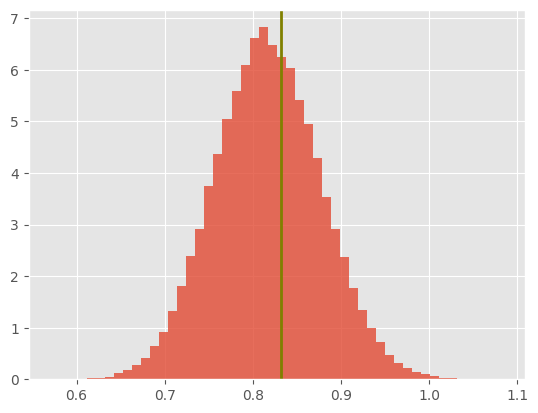

In [46]:
plt.hist(np.exp(us)[:,0], bins=50, alpha=0.8, density=True);
plt.axvline(u_true[0], c="olive", linewidth=2)

In [24]:
def autocovariance(x, max_lag=None):
    x = np.asarray(x)
    n = len(x)
    x_centered = x - np.mean(x)

    if max_lag is None:
        max_lag = n - 1

    acov = np.empty(max_lag + 1)
    for k in range(max_lag + 1):
        acov[k] = np.dot(x_centered[:n-k], x_centered[k:]) / (n - k)
    return acov

def autocorrelation(x, max_lag=None):
    acov = autocovariance(x, max_lag=max_lag)
    return acov / acov[0]

def ess_initial_positive(x, max_lag=None):
    rho = autocorrelation(x, max_lag=max_lag)

    # exclude lag 0
    positive_rhos = []
    for r in rho[1:]:
        if r < 0:
            break
        positive_rhos.append(r)

    tau_int = 1 + 2 * np.sum(positive_rhos)
    ess = len(x) / tau_int
    return ess, rho

In [30]:
ess_initial_positive(np.exp(us)[:, 3])

(np.float64(712.2788136777159),
 array([1.        , 0.98345018, 0.96726536, ..., 0.07015839, 0.07943655,
        0.07943655], shape=(100000,)))

In [33]:
100000 // 500

200

In [34]:
100000 // 700

142

In [ ]:
y_obs = np.array(
    [
        114.48129002,
        44.0285498,
        2.84067379,
        33.59841612,
        3.18425621,
        9.04750612,
        23.86320385,
        1.01129943,
        63.12901173,
        8.5263012,
        5.88006215,
        52.18204437,
        3.05408562,
        9.85829968,
        6.34684549,
        1.22521925,
        40.56389563,
        0.95755453,
    ]
)

In [36]:
y_cond = np.load("y_obs.npy")
np.exp(y_cond)

array([106.29417377,  26.0955674 ,   2.62773345,  35.52353099,
         3.85090825,   5.036432  ,  16.62323365,   1.1426782 ,
        78.3481832 ,   3.26524741,   6.96299637,  70.70011966,
         2.59301152,  10.30570296,   9.31703421,   1.7626866 ,
        44.60402247,   1.2157957 ])

In [37]:
50000 / 2500

20.0

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [18]:
us_rare = np.load("true_samps/true_us_rare_obs.npy")

In [19]:
2.38 ** 2 / 4

1.4161

In [20]:
cov = np.cov(us_rare) * (2.38 ** 2 / 4)

In [21]:
cov

array([[4.34385789, 4.34385789, 4.34385789, ..., 1.40382006, 1.40382006,
        1.40382006],
       [4.34385789, 4.34385789, 4.34385789, ..., 1.40382006, 1.40382006,
        1.40382006],
       [4.34385789, 4.34385789, 4.34385789, ..., 1.40382006, 1.40382006,
        1.40382006],
       ...,
       [1.40382006, 1.40382006, 1.40382006, ..., 4.07691312, 4.07691312,
        4.07691312],
       [1.40382006, 1.40382006, 1.40382006, ..., 4.07691312, 4.07691312,
        4.07691312],
       [1.40382006, 1.40382006, 1.40382006, ..., 4.07691312, 4.07691312,
        4.07691312]], shape=(5000, 5000))

In [35]:
np.mean(np.diag(cov))

np.float64(3.121602034913818)

In [7]:
cov[1, :]

array([6.27129639, 6.27129639, 6.27129639, ..., 6.32839067, 6.32839067,
       6.32839067], shape=(5000,))

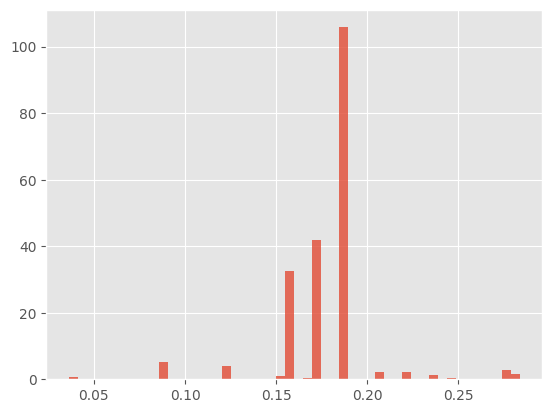

In [32]:
plt.hist(np.exp(us_rare)[:,3], bins=50, alpha=0.8, density=True);
# plt.axvline(u_true[3], c="olive", linewidth=2)